Enter your Kaggle API token in .env

In [110]:
from dotenv import load_dotenv
import os
load_dotenv()
if 'input' not in os.listdir():
    !mkdir input
    !kaggle datasets download olistbr/brazilian-ecommerce
    !unzip brazilian-ecommerce.zip -d ./input/
    !rm brazilian-ecommerce.zip


# Chapter 1: Reconnaissance

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler


In [112]:
data = {}
for filename in os.listdir('input'):
    name = filename[:-4].removeprefix('olist_').removesuffix('_dataset')
    data[name] = pd.read_csv(f'input/{filename}')
[k for k in data.keys()]


['order_payments',
 'products',
 'sellers',
 'orders',
 'customers',
 'order_items',
 'order_reviews',
 'geolocation',
 'product_category_name_translation']

Domains of interest:
1. Logistics
2. Sells
3. Quality

Lets find out relevant data for each one.
To do this we need to investigate the content of datatables

## Datatables

### order_payments

In [113]:
data['order_payments'].head(2)



,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [114]:
data['order_payments'].info()


<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


### products

In [115]:
data['products'].head(2)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [116]:
data['products'].info()


<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


### sellers

In [117]:
data['sellers'].head(2)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


In [118]:
data['sellers'].info()


<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


### orders

In [119]:
data['orders'].head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [120]:
data['orders'].info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


### customers

In [121]:
data['customers'].head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [122]:
data['customers'].info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


### order_items


In [123]:
data['order_items'].head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [124]:
data['order_items'].info()


<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


### order_reviews

In [125]:
data['order_reviews'].head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [126]:
data['order_reviews'].info()


<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


### geolocation

In [127]:
data['geolocation'].head()


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [128]:
data['geolocation'].info()


<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB


### product_category_name_translation

In [129]:
data['product_category_name_translation'].head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [130]:
data['product_category_name_translation'].info()


<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 1.2 KB


# Chapter 2: Investigation by domains

## Logistics department

Issues:
1. Increase of delivery term
2. Clients' dissapointment

First insight is that the most important metrics there is the share and number of negative reviews.\
This info could be found in **order_reviews**

In [131]:
df = data['order_reviews']


In [132]:
print('Mean rating', df['review_score'].mean())

df['review_score'].value_counts()


Mean rating 4.08642062404257


review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

Lets find out what happened on a timeline

### Review scores' amount and share

In [133]:
df['review_creation_date'] = pd.to_datetime(df['review_creation_date'])
print(df['review_creation_date'].min())
df['review_creation_date'].max()


2016-10-02 00:00:00


Timestamp('2018-08-31 00:00:00')

In [134]:
year_month = df['review_creation_date'].dt.to_period('M')
g = (
    df
    .groupby([year_month, 'review_score'])
    .size()
    .reset_index(name='count')
    .rename(columns={'review_creation_date': 'review_creation_month'})
)
g


,review_creation_month,review_score,count
0,2016-10,1,25
1,2016-10,2,4
2,2016-10,3,13
3,2016-10,4,31
4,2016-10,5,106
...,...,...,...
109,2018-08,1,841
110,2018-08,2,251
111,2018-08,3,644
112,2018-08,4,1697


In [135]:
p = g.pivot(index='review_creation_month', columns='review_score', values='count')
p.head()


review_score,1,2,3,4,5
review_creation_month,,,,,
2016-10,25.0,4.0,13.0,31.0,106.0
2016-11,34.0,4.0,8.0,19.0,36.0
2016-12,29.0,NaN,1.0,1.0,14.0
2017-01,17.0,3.0,23.0,35.0,161.0
2017-02,96.0,39.0,120.0,275.0,883.0


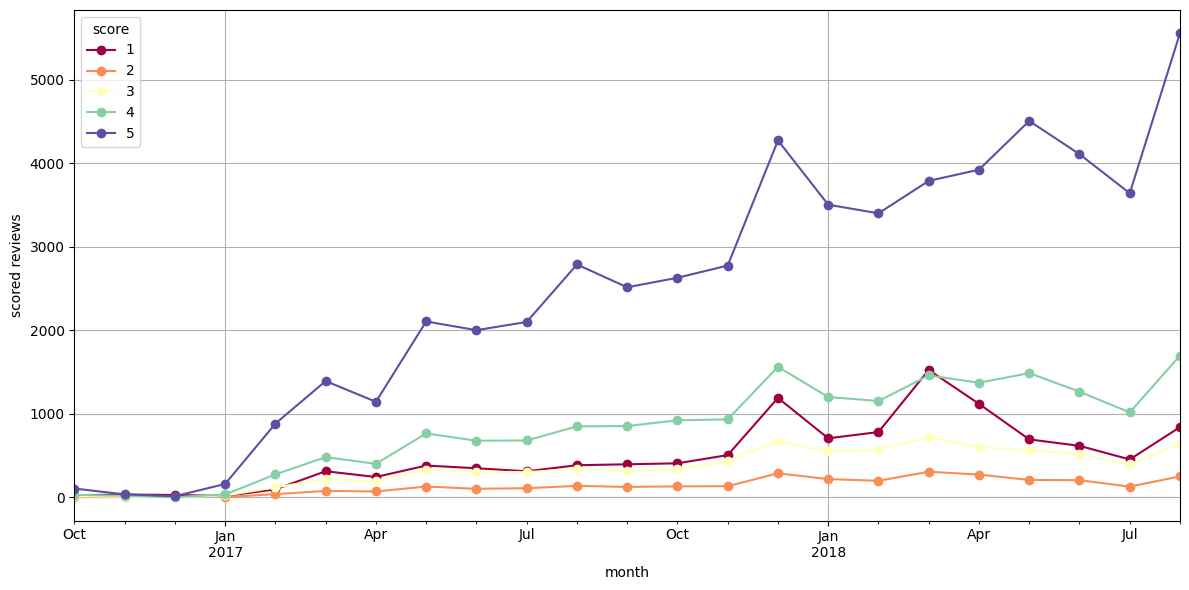

In [136]:
p.plot(kind='line', marker='o', figsize=(12, 6), colormap='Spectral')
plt.xlabel('month')
plt.ylabel('scored reviews')
plt.legend(title='score')
plt.grid(True)
plt.xticks()
plt.tight_layout()
plt.show()


In [137]:
total_reviews = g.groupby('review_creation_month')['count'].sum()

g['total'] = g['review_creation_month'].map(total_reviews)
g['percent'] = (g['count'] / g['total']) * 100
g


,review_creation_month,review_score,count,total,percent
0,2016-10,1,25,179,13.966480
1,2016-10,2,4,179,2.234637
2,2016-10,3,13,179,7.262570
3,2016-10,4,31,179,17.318436
4,2016-10,5,106,179,59.217877
...,...,...,...,...,...
109,2018-08,1,841,8987,9.357961
110,2018-08,2,251,8987,2.792923
111,2018-08,3,644,8987,7.165906
112,2018-08,4,1697,8987,18.882831


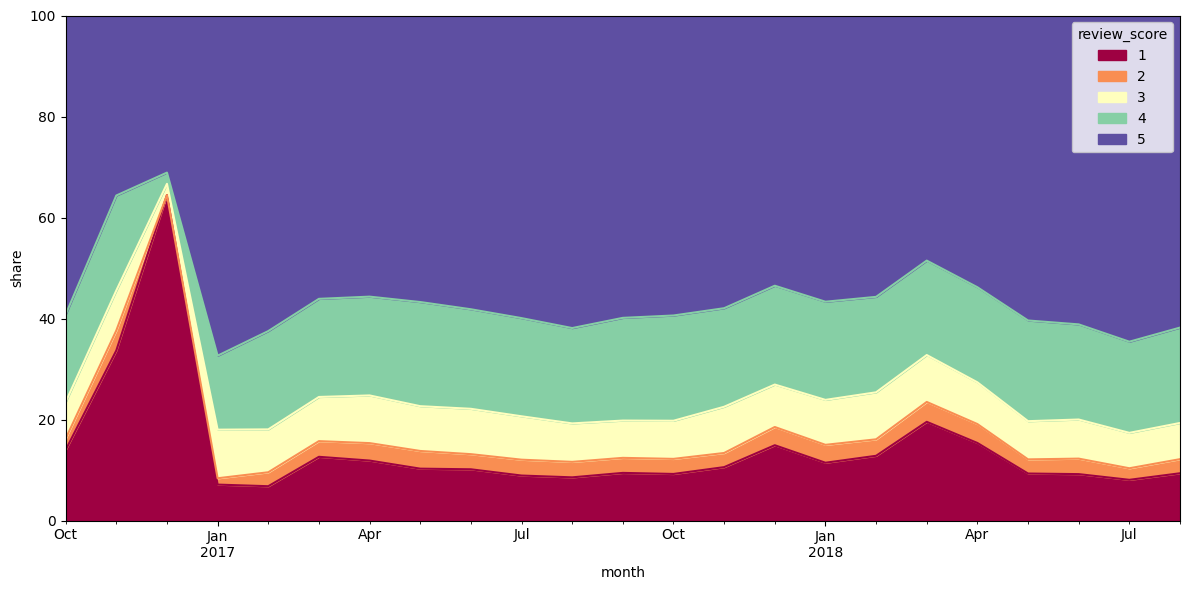

In [138]:
p2 = g.pivot(index='review_creation_month', columns='review_score', values='percent')
p2.plot(kind='area', stacked=True, figsize=(12, 6), colormap='Spectral')
plt.xlabel('month')
plt.ylabel('share')
plt.legend(title='review_score')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


Intermediate conclusion - there is no surge in negative reviews last time. However, there is increase in number of reviews overall

### Delivery term

In [139]:
df = data['orders']


In [140]:
df["delivery_term"] = pd.to_datetime(df["order_purchase_timestamp"]) - pd.to_datetime(df["order_delivered_customer_date"])


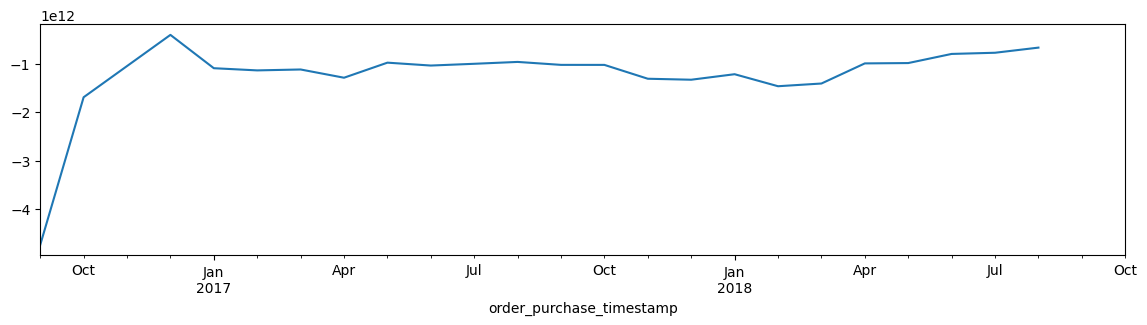

In [141]:
g = df.groupby(
    pd.to_datetime(df["order_purchase_timestamp"]).dt.to_period('M')
)['delivery_term'].mean().plot(figsize=(14, 3))



In [142]:
df['delivery_term_exceeded'] = pd.to_datetime(df['order_estimated_delivery_date']) < pd.to_datetime(df['order_delivered_customer_date']).dt.normalize()
df['delivery_term_exceeded']


0        False
1        False
2        False
3        False
4        False
         ...  
99436    False
99437    False
99438    False
99439    False
99440    False
Name: delivery_term_exceeded, Length: 99441, dtype: bool

In [143]:
df.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_term', 'delivery_term_exceeded'],
      dtype='str')

In [144]:
g = df.groupby(pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M'))['delivery_term_exceeded'].mean()


In [145]:
g.corr(
    data['order_reviews'].groupby(pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M'))['review_score'].mean(),
)


np.float64(0.3115276868786272)

### Impact on reviews

In [146]:
ord_n_ordrev = pd.merge(
    data['order_reviews'],
    data['orders'],
    how='right',
    on='order_id'
)

ord_n_ordrev.info()


<class 'pandas.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   review_id                      99224 non-null  str            
 1   order_id                       99992 non-null  str            
 2   review_score                   99224 non-null  float64        
 3   review_comment_title           11568 non-null  str            
 4   review_comment_message         40977 non-null  str            
 5   review_creation_date           99224 non-null  datetime64[us] 
 6   review_answer_timestamp        99224 non-null  str            
 7   customer_id                    99992 non-null  str            
 8   order_status                   99992 non-null  str            
 9   order_purchase_timestamp       99992 non-null  str            
 10  order_approved_at              99831 non-null  str            
 11  order_deliver

In [147]:
print( '',
    ord_n_ordrev.loc[ord_n_ordrev['delivery_term_exceeded']]['review_score'].mean(),
    ord_n_ordrev.loc[ord_n_ordrev['delivery_term_exceeded']]['delivery_term'].mean(),
)
print(
    ord_n_ordrev.loc[~ord_n_ordrev['delivery_term_exceeded']]['review_score'].mean(),
    ord_n_ordrev.loc[~ord_n_ordrev['delivery_term_exceeded']]['delivery_term'].mean(),
)


 2.271138845553822 -34 days +00:40:39.730459
4.211789169737324 -12 days +23:44:00.667301


<Axes: ylabel='Frequency'>

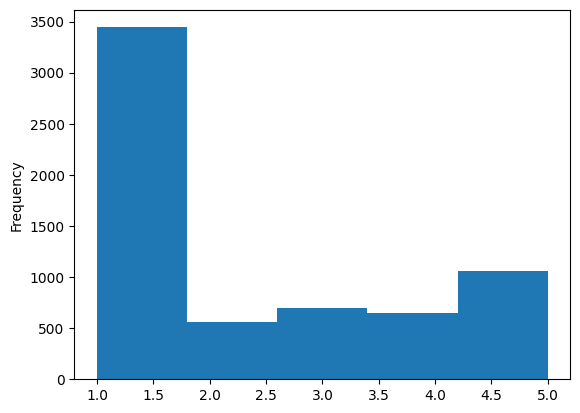

In [148]:
ord_n_ordrev.loc[ord_n_ordrev['delivery_term_exceeded']]['review_score'].plot(kind='hist', bins=5)


<Axes: ylabel='Frequency'>

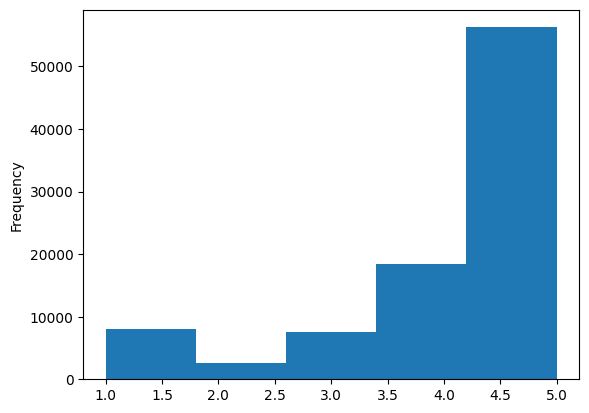

In [149]:
ord_n_ordrev.loc[~ord_n_ordrev['delivery_term_exceeded']]['review_score'].plot(kind='hist', bins=5)


### Dive into logistic legs

In [150]:
df = data['orders']


In [151]:
df['approval_term'] = pd.to_datetime(df['order_approved_at']) - pd.to_datetime(df['order_purchase_timestamp'])
df['1st_leg'] = pd.to_datetime(df['order_delivered_carrier_date']) - pd.to_datetime(df['order_approved_at'])
df['2nd_leg'] = pd.to_datetime(df['order_delivered_customer_date']) - pd.to_datetime(df['order_delivered_carrier_date'])


In [152]:
(
    df.groupby(pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M'))
    .agg(
        {
            'approval_term': 'mean',
            '1st_leg': 'mean',
            '2nd_leg': 'mean',
        }
    )
)


,approval_term,1st_leg,2nd_leg
order_purchase_timestamp,,,
2016-09,22 days 06:44:13,32 days 02:26:01.500000,1 days 14:35:45
2016-10,1 days 12:23:42.106918,13 days 03:35:17.985611,5 days 19:35:06.925925
2016-12,0 days 00:14:50,3 days 06:42:50,1 days 09:40:17
2017-01,0 days 11:41:28.314930,2 days 23:44:52.523560,9 days 04:46:25.570666
2017-02,0 days 10:17:42.578142,3 days 07:00:34.688929,9 days 12:50:50.061101
2017-03,0 days 06:00:41.598134,2 days 21:07:55.068313,9 days 20:00:06.071877
2017-04,0 days 13:19:43.402916,3 days 03:26:01.273384,11 days 05:38:34.541033
2017-05,0 days 10:00:14.871850,2 days 13:38:08.734722,8 days 08:09:56.871368
2017-06,0 days 09:28:32.225547,2 days 17:49:00.980201,8 days 21:06:48.584688


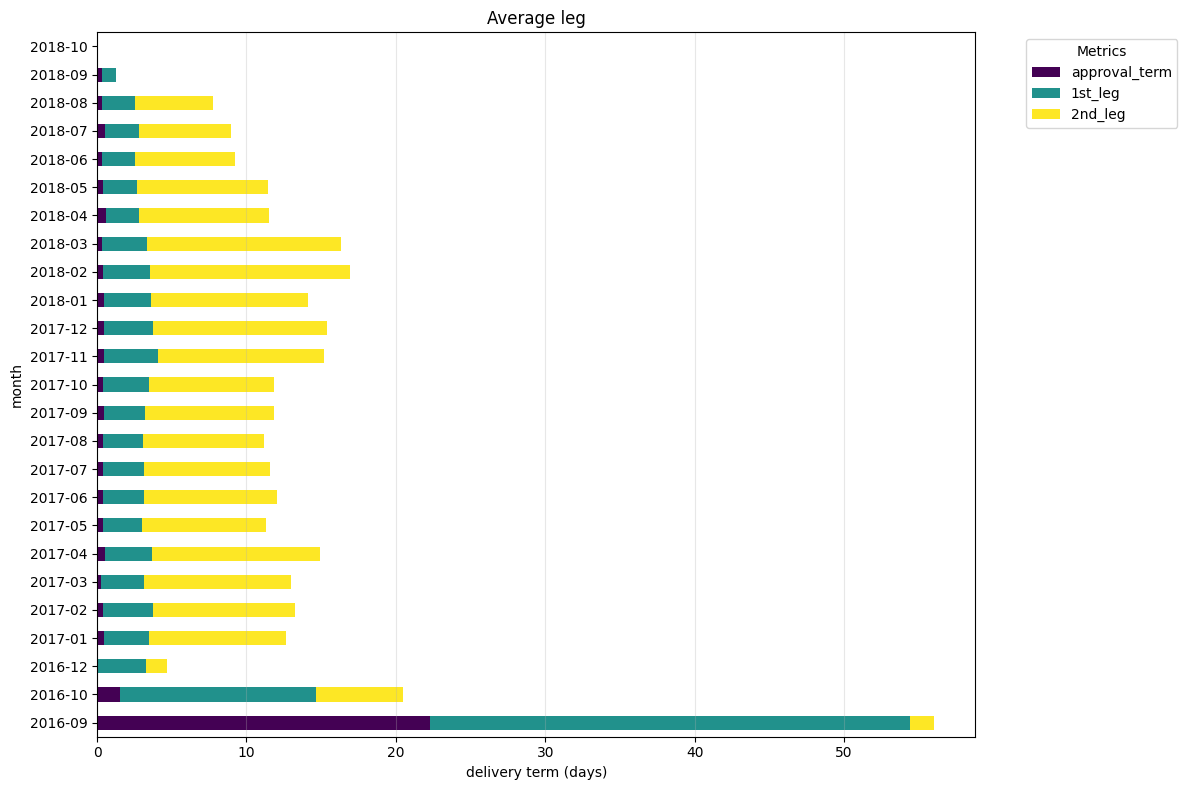

In [160]:
def convert_timedelta_to_days(df, columns):
    for col in columns:
        df[col] = df[col].dt.total_seconds() / (24 * 3600)
    return df

result = df.groupby(pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')).agg(
    {
        'approval_term': 'mean',
        '1st_leg': 'mean',
        '2nd_leg': 'mean',
    }
)

result = convert_timedelta_to_days(result, ['approval_term', '1st_leg', '2nd_leg'])

result.index = result.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 8))

result.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    colormap='viridis'
)

ax.set_xlabel('delivery term (days)')
ax.set_ylabel('month')
ax.set_title('Average leg')
ax.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Dive into distances (SQL)

In [154]:
import duckdb


In [223]:
(res := 
    duckdb.sql(
    """
    with
    cust_geo as (
    select
        c.customer_id,
        c.customer_zip_code_prefix,
        avg(g.geolocation_lat) as geolocation_lat,
        avg(g.geolocation_lng) as geolocation_lng
    from
        'input/olist_customers_dataset.csv' c
    join
        'input/olist_geolocation_dataset.csv' g
    on
        c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
    group by
        c.customer_id, c.customer_zip_code_prefix
    ),
    sel_geo as (
    select
        s.seller_id,
        s.seller_zip_code_prefix,
        avg(g.geolocation_lat) as geolocation_lat,
        avg(g.geolocation_lng) as geolocation_lng
    from
        'input/olist_sellers_dataset.csv' s
    join
        'input/olist_geolocation_dataset.csv' g
    on
        s.seller_zip_code_prefix = g.geolocation_zip_code_prefix
    group by
        s.seller_id, s.seller_zip_code_prefix
    ),
    ord_cust_geo as (
        select
            *
        from
            'input/olist_orders_dataset.csv' o
        join
            cust_geo
            on
            cust_geo.customer_id = o.customer_id
    ),
    ord_cust_farthest_seller as(
        select
            oi.order_id,
            any_value(ocg.order_purchase_timestamp) as order_date,
            date_diff(
                'day',
                any_value(ocg.order_delivered_carrier_date),
                any_value(ocg.order_delivered_customer_date)
            ) as second_leg,
            max(
                round(sqrt(
                    pow(ocg.geolocation_lat - sg.geolocation_lat, 2) + pow(ocg.geolocation_lng - sg.geolocation_lng, 2)
                ), 2)
            ) as seller_customer_max_distance
        from
            'input/olist_order_items_dataset.csv' oi
        join
            ord_cust_geo ocg
            on
            ocg.order_id = oi.order_id
        join
            sel_geo sg
            on
            sg.seller_id = oi.seller_id
        group by
            oi.order_id
    )

    select
        date_trunc('month', order_date) as order_month,
        count(*) as total_orders,
        avg(seller_customer_max_distance) as avg_distance,
        avg(second_leg) as avg_delivery_days,
        avg(seller_customer_max_distance / nullif(second_leg, 0)) as avg_distance_per_day_ratio,
        median(seller_customer_max_distance / nullif(second_leg, 0)) as median_distance_per_day,
        stddev(seller_customer_max_distance / nullif(second_leg, 0)) as ratio_stddev
    from
        ord_cust_farthest_seller
    where 
        second_leg > 0 
        and seller_customer_max_distance > 0
        and order_date is not null
    group by
        date_trunc('month', order_date)
    order by
        order_month

    """
    ).df()
)


,order_month,total_orders,avg_distance,avg_delivery_days,avg_distance_per_day_ratio,median_distance_per_day,ratio_stddev
0,2016-09-01,1,5.120000,2.000000,2.560000,2.560000,NaN
1,2016-10-01,259,5.968069,6.081081,1.507111,0.895000,2.128055
2,2016-12-01,1,0.100000,1.000000,0.100000,0.100000,NaN
3,2017-01-01,743,5.858183,9.258412,0.745322,0.568500,0.706758
4,2017-02-01,1648,6.028538,9.556432,0.721243,0.562614,0.695735
5,2017-03-01,2529,5.951439,9.788849,0.764757,0.604286,0.936960
6,2017-04-01,2288,6.313243,11.208916,0.657113,0.513333,0.609092
7,2017-05-01,3522,5.903949,8.304656,0.785642,0.613767,0.743780
8,2017-06-01,3094,5.479945,8.868455,0.664305,0.523205,0.611947
9,2017-07-01,3822,5.738425,8.510727,0.723916,0.586786,0.635917


### Dive into categories (SQL)

In [222]:
(res2 :=
    duckdb.sql(
    """
    with
    cust_geo as (
        select
            c.customer_id,
            c.customer_zip_code_prefix,
            avg(g.geolocation_lat) as geolocation_lat,
            avg(g.geolocation_lng) as geolocation_lng
        from 'input/olist_customers_dataset.csv' c
        join 'input/olist_geolocation_dataset.csv' g
            on c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
        group by c.customer_id, c.customer_zip_code_prefix
    ),
    sel_geo as (
        select
            s.seller_id,
            s.seller_zip_code_prefix,
            avg(g.geolocation_lat) as geolocation_lat,
            avg(g.geolocation_lng) as geolocation_lng
        from 'input/olist_sellers_dataset.csv' s
        join 'input/olist_geolocation_dataset.csv' g
            on s.seller_zip_code_prefix = g.geolocation_zip_code_prefix
        group by s.seller_id, s.seller_zip_code_prefix
    ),
    ord_cust_geo as (
        select o.*, cg.geolocation_lat, cg.geolocation_lng
        from 'input/olist_orders_dataset.csv' o
        join cust_geo cg on cg.customer_id = o.customer_id
    ),
    order_category_legs as (
            select
                oi.order_id,
                oi.seller_id,
                coalesce(t.product_category_name_english, p.product_category_name) as category,
                count(*) as item_count,
            any_value(ocg.order_purchase_timestamp) as order_date,
            any_value(ocg.order_estimated_delivery_date) as estimated_delivery,
            any_value(ocg.order_delivered_customer_date) as delivered_date,
            date_diff(
                'day',
                any_value(ocg.order_delivered_carrier_date),
                any_value(ocg.order_delivered_customer_date)
            ) as second_leg,
            max(round(sqrt(
                pow(ocg.geolocation_lat - sg.geolocation_lat, 2) +
                pow(ocg.geolocation_lng - sg.geolocation_lng, 2)
            ), 2)) as seller_customer_max_distance
        from 'input/olist_order_items_dataset.csv' oi
        join ord_cust_geo ocg on ocg.order_id = oi.order_id
        join sel_geo sg on sg.seller_id  = oi.seller_id
        join 'input/olist_products_dataset.csv' p
            on p.product_id = oi.product_id
        left join 'input/product_category_name_translation.csv' t
            on t.product_category_name = p.product_category_name
        group by oi.order_id, oi.seller_id, category
    )

    select
        category,
        count(*) as total_orders,
        avg(item_count) as avg_items_per_order, 
        avg(second_leg) as avg_2nd_leg_days,
        median(second_leg) as median_2nd_leg_days,
        avg(seller_customer_max_distance) as avg_distance,
        sum(case when delivered_date > estimated_delivery then 1 end) as delivery_term_exceeded,
        round(
            sum(case when delivered_date > estimated_delivery then 1 end)
            * 100.0 / count(*), 2
        ) as late_pct
    from order_category_legs
    where
        second_leg > 0
        and seller_customer_max_distance > 0
        and order_date is not null
    group by category
    order by late_pct desc
    """
    ).df()
)


,category,total_orders,avg_items_per_order,avg_2nd_leg_days,median_2nd_leg_days,avg_distance,delivery_term_exceeded,late_pct
0,home_comfort_2,24,1.250000,12.000000,9.0,4.370417,4.0,16.67
1,furniture_mattress_and_upholstery,37,1.000000,11.594595,6.0,2.487297,5.0,13.51
2,audio,345,1.040580,10.521739,7.0,5.274957,45.0,13.04
3,fashion_underwear_beach,117,1.085470,9.717949,7.0,5.151880,15.0,12.82
4,books_technical,256,1.027344,8.281250,6.0,5.116250,28.0,10.94
...,...,...,...,...,...,...,...,...
69,security_and_services,2,1.000000,13.500000,13.5,12.800000,NaN,NaN
70,fashion_childrens_clothes,7,1.000000,7.000000,5.0,4.938571,NaN,NaN
71,pc_gamer,7,1.142857,7.571429,7.0,5.637143,NaN,NaN
72,cds_dvds_musicals,12,1.166667,8.250000,7.5,4.399167,NaN,NaN


<Axes: >

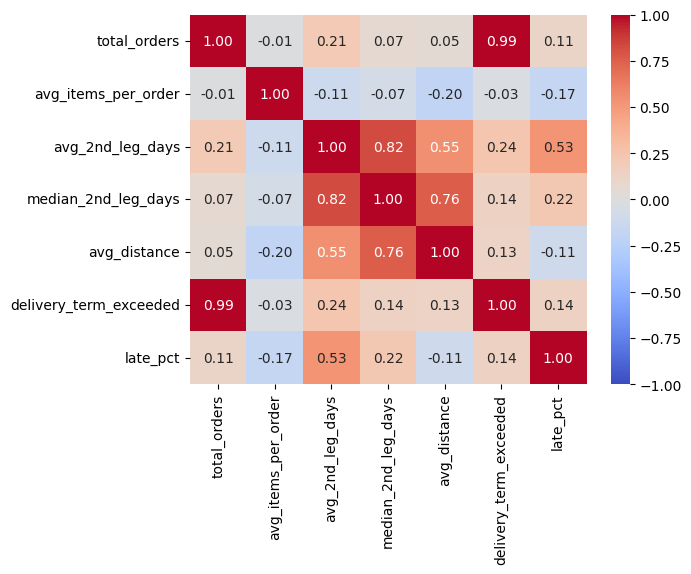

In [ ]:
res2_n = res2.iloc[:, 1:]
res2_n = pd.DataFrame(
    MinMaxScaler().fit_transform(res2_n), #unnecessary
    columns=res2.columns[1:]
)

sns.heatmap(
    res2_n.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
)


### Dive into dimensions (SQL)

In [236]:
(res3 :=
duckdb.sql(
"""
with
cust_geo as (
select
    c.customer_id,
    c.customer_zip_code_prefix,
    avg(g.geolocation_lat) as geolocation_lat,
    avg(g.geolocation_lng) as geolocation_lng
from 'input/olist_customers_dataset.csv' c
join 'input/olist_geolocation_dataset.csv' g
on c.customer_zip_code_prefix = g.geolocation_zip_code_prefix
group by c.customer_id, c.customer_zip_code_prefix
),
sel_geo as (
select
    s.seller_id,
    s.seller_zip_code_prefix,
    avg(g.geolocation_lat) as geolocation_lat,
    avg(g.geolocation_lng) as geolocation_lng
from 'input/olist_sellers_dataset.csv' s
join 'input/olist_geolocation_dataset.csv' g
on s.seller_zip_code_prefix = g.geolocation_zip_code_prefix
group by s.seller_id, s.seller_zip_code_prefix
),
ord_cust_geo as (
select o.*, cg.geolocation_lat, cg.geolocation_lng
from 'input/olist_orders_dataset.csv' o
join cust_geo cg on cg.customer_id = o.customer_id
),
single_item_orders as (
select order_id
from 'input/olist_order_items_dataset.csv'
group by order_id
having count(*) = 1
),
order_legs as (
select
    oi.order_id,
    oi.product_id,
    coalesce(t.product_category_name_english, p.product_category_name) as category,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm,
    round(p.product_length_cm * p.product_height_cm * p.product_width_cm / 1000.0, 2) as volume_liters,
    round(p.product_length_cm * p.product_height_cm * p.product_width_cm / 5000.0, 2) as dim_weight_g,
    ocg.order_purchase_timestamp as order_date,
    ocg.order_estimated_delivery_date as estimated_delivery,
    ocg.order_delivered_customer_date as delivered_date,
    date_diff('day', ocg.order_delivered_carrier_date, ocg.order_delivered_customer_date) as second_leg,
    round(sqrt(
        pow(ocg.geolocation_lat - sg.geolocation_lat, 2) +
        pow(ocg.geolocation_lng - sg.geolocation_lng, 2)
    ), 2) as distance
from 'input/olist_order_items_dataset.csv' oi
join single_item_orders sio on sio.order_id = oi.order_id
join ord_cust_geo ocg on ocg.order_id = oi.order_id
join sel_geo sg on sg.seller_id = oi.seller_id
join 'input/olist_products_dataset.csv' p on p.product_id = oi.product_id
left join 'input/product_category_name_translation.csv' t on t.product_category_name = p.product_category_name
)
select
    count(*) as total_orders,
    round(avg(product_weight_g), 1) as avg_weight_g,
    round(avg(volume_liters), 2) as avg_volume_liters,
    round(avg(dim_weight_g), 1) as avg_dim_weight_g,
    sum(case when delivered_date > estimated_delivery then 1 end) as late_count,
    round(sum(case when delivered_date > estimated_delivery then 1 end) * 100.0 / count(*), 2) as late_pct,
    round(corr(product_weight_g, case when delivered_date > estimated_delivery then 1.0 else 0.0 end), 3) as weight_late_corr,
    round(corr(volume_liters, case when delivered_date > estimated_delivery then 1.0 else 0.0 end), 3) as volume_late_corr,
    round(corr(dim_weight_g, case when delivered_date > estimated_delivery then 1.0 else 0.0 end), 3) as dim_weight_late_corr
from order_legs
where
    second_leg > 0
    and distance > 0
    and order_date is not null
    and product_weight_g is not null
    and volume_liters is not null
"""
).df()
)


,total_orders,avg_weight_g,avg_volume_liters,avg_dim_weight_g,late_count,late_pct,weight_late_corr,volume_late_corr,dim_weight_late_corr
0,86102,2105.6,15.17,3.0,7130.0,8.28,0.024,0.02,0.02


### Key insights

1. There is a surge in negative reviews in 2018.03
2. It corresponds to increase of 2nd leg delivery term in 2018.02, 2018.03
3. The orders with delivery term exceeding estimated one get the most 1/5 ratings
4. The distance does not explain late (no correlation)

### Key metrics

In [156]:
print( 'General delivery term violation:',
    round(
        ord_n_ordrev.loc[ord_n_ordrev['delivery_term_exceeded']]['review_score'].count()
        / ord_n_ordrev['delivery_term_exceeded'].size * 100,
        2
    ),
    '%'
)

pd.crosstab(
    index=pd.to_datetime(ord_n_ordrev['order_purchase_timestamp']).dt.to_period('M'),
    columns=ord_n_ordrev['delivery_term_exceeded'],
    normalize='index'
) * 100


General delivery term violation: 6.41 %


delivery_term_exceeded,False,True
order_purchase_timestamp,,
2016-09,75.000000,25.000000
2016-10,99.386503,0.613497
2016-12,100.000000,0.000000
2017-01,97.273854,2.726146
2017-02,97.259508,2.740492
2017-03,95.698925,4.301075
2017-04,93.695562,6.304438
2017-05,97.163500,2.836500
2017-06,97.101007,2.898993


In [157]:
df.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_term', 'delivery_term_exceeded', 'approval_term', '1st_leg',
       '2nd_leg'],
      dtype='str')

In [158]:
march_2018 = (
    pd.to_datetime('2018-03-01') <= pd.to_datetime(df['order_purchase_timestamp'])
    ) & (
    pd.to_datetime(df['order_purchase_timestamp']) < pd.to_datetime('2018-04-01')
    )

print(df.loc[march_2018, '2nd_leg'].mode()[0])
print(df['2nd_leg'].mode()[0])


7 days 01:28:02
3 days 00:00:00


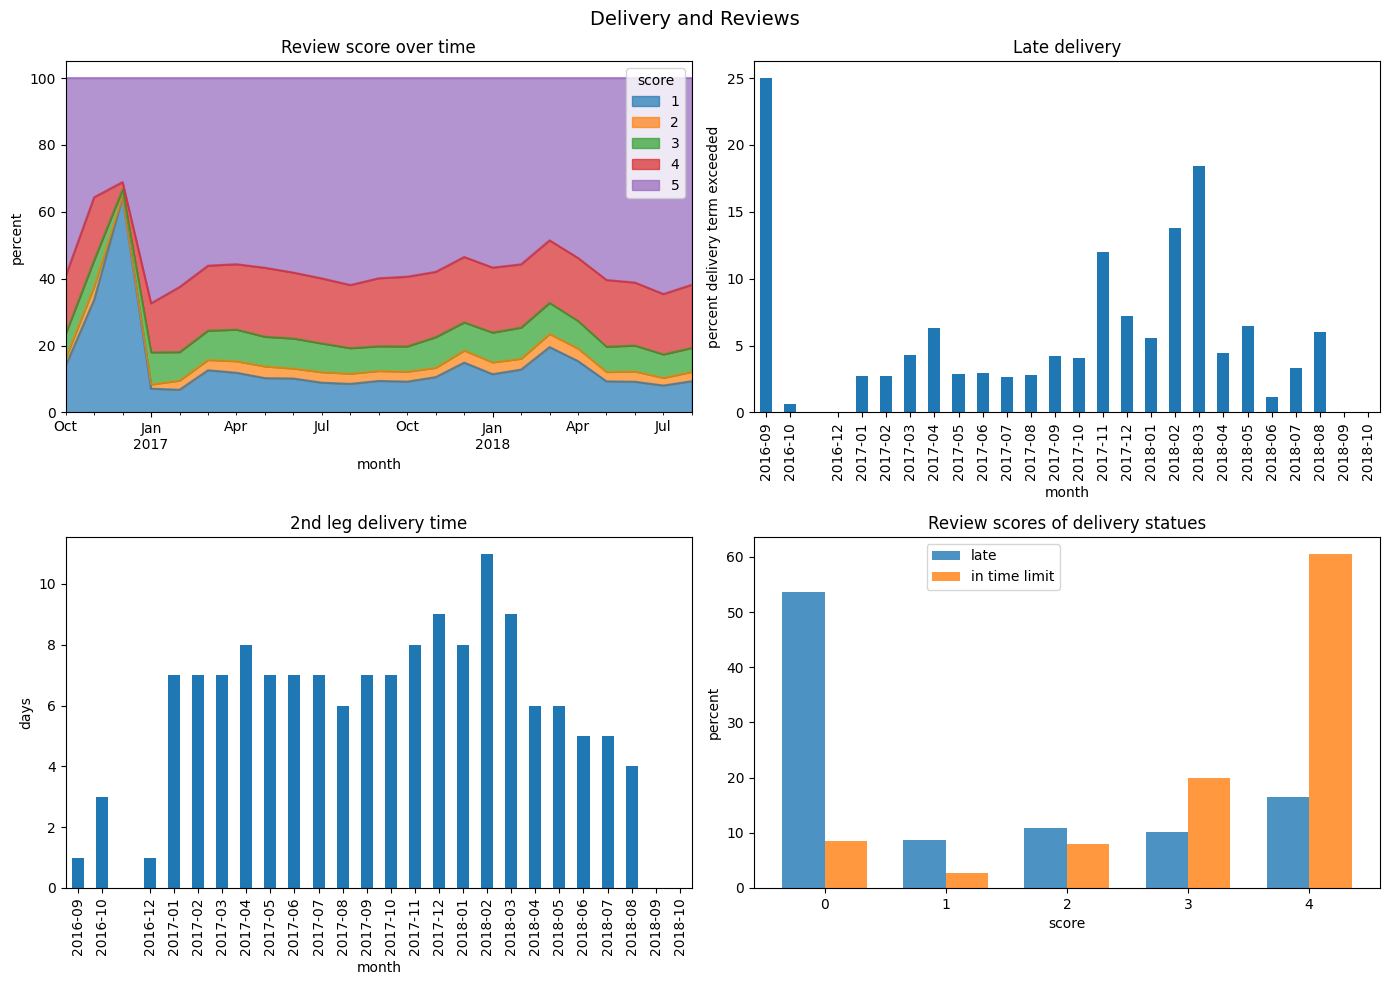

In [ ]:
reviews = data['order_reviews'].copy()
orders = data['orders'].copy()

reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])

orders['delivery_term_exceeded'] = orders['order_estimated_delivery_date'] < orders['order_delivered_customer_date'].dt.normalize()
orders['2nd_leg_days'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.days
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

ord_rev = pd.merge(reviews, orders, on='order_id', how='right')

rev_month = reviews.copy()
rev_month['month'] = reviews['review_creation_date'].dt.to_period('M')
score_dist = rev_month.groupby(['month', 'review_score']).size().unstack(fill_value=0)
score_dist_pct = score_dist.div(score_dist.sum(axis=1), axis=0) * 100

late_rate = orders.groupby('month')['delivery_term_exceeded'].mean() * 100
leg2_median = orders.groupby('month')['2nd_leg_days'].median()

late_scores = ord_rev[ord_rev['delivery_term_exceeded']]['review_score'].dropna()
ontime_scores = ord_rev[~ord_rev['delivery_term_exceeded']]['review_score'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Delivery and Reviews', fontsize=14)

score_dist_pct.plot.area(ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Review score over time')
axes[0,0].set_ylabel('percent')
axes[0,0].legend(title='score')

late_rate.plot.bar(ax=axes[0,1])
axes[0,1].set_title('Late delivery')
axes[0,1].set_ylabel('percent delivery term exceeded')

leg2_median.plot.bar(ax=axes[1,0])
axes[1,0].set_title('2nd leg delivery time')
axes[1,0].set_ylabel('days')

bins = [1,2,3,4,5]
late_pct = late_scores.value_counts(normalize=True).reindex(bins, fill_value=0) * 100
ontime_pct = ontime_scores.value_counts(normalize=True).reindex(bins, fill_value=0) * 100

x = np.arange(len(bins))
width = 0.35
axes[1,1].bar(x - width/2, late_pct, width, label='late', alpha=0.8)
axes[1,1].bar(x + width/2, ontime_pct, width, label='in time limit', alpha=0.8)
axes[1,1].set_title('Review scores of delivery statuses')
axes[1,1].set_xlabel('score')
axes[1,1].set_ylabel('percent')
axes[1,1].set_xticks(x)
axes[1,1].legend(bbox_to_anchor=(0.5, 1))

plt.tight_layout()
plt.savefig('dashboard.png')
plt.show()
